## Classifier genre scores on different models for test set MIDI starts and custom MIDI starts


In [2]:
from jazzgen.evaluation_utils import run_dataset_eval, compute_genre_stats
from jazzgen.modeling_utils import load_model
import os
import json

custom_dataset = os.path.join("..", "data", "custom")
test_dataset = os.path.join("..", "data", "test")

### Baseline model

Custom dataset.

In [3]:
tokenizer, model = load_model()

save_path = os.path.join(custom_dataset, "results", "baseline_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(custom_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [4]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.29297486824780206,
 'std': 0.21600270061604282,
 'min': 0.019832001729810145,
 'max': 0.9517472317093052,
 'n': 240}

In [5]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.3160214638741005,
 'std': 0.20281612823398162,
 'min': 0.017864370933239115,
 'max': 0.9036149729508907,
 'n': 240}

Test dataset.

In [6]:
tokenizer, model = load_model()

save_path = os.path.join(test_dataset, "results", "baseline_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(test_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [7]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.34495338440306966,
 'std': 0.21535031060612325,
 'min': 0.0452262908074772,
 'max': 0.9125819710170617,
 'n': 256}

In [8]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.22565112571000334,
 'std': 0.1829130102918129,
 'min': 0.005867771783414355,
 'max': 0.8080365363275632,
 'n': 256}

In [9]:
import json
import os

def get_best_eval_step(path):
    """
    Return the step where eval_loss is smallest in a Hugging Face trainer_state.json file.
    """
    with open(path, "r") as f:
        state = json.load(f)

    best_row = None

    for row in state["log_history"]:
        if "eval_loss" in row:
            if best_row is None or row["eval_loss"] < best_row["eval_loss"]:
                best_row = row

    if best_row is None:
        raise ValueError("No eval_loss found in log_history.")

    return best_row["step"]

def best_model_path(config=("att", 16)):
    path = os.path.join("..", "fine_tuning", f"aria_lora_{config[0]}_{config[1]}", "checkpoint-3385", "trainer_state.json")
    best_step = get_best_eval_step(path)
    return os.path.join("..", "fine_tuning", f"aria_lora_{config[0]}_{config[1]}", f"checkpoint-{best_step}")


### Attention Only Finetuned Model - r = 16 

Custom dataset.

In [10]:
tokenizer, model = load_model(best_model_path(("att", 16)))

save_path = os.path.join(custom_dataset, "results", "att16_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(custom_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [11]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.39354030648852356,
 'std': 0.2501899736963817,
 'min': 0.0114093818647234,
 'max': 0.9563850814665784,
 'n': 240}

In [12]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.20020165564580072,
 'std': 0.18109402028170452,
 'min': 0.007649803934327792,
 'max': 0.9108614076758386,
 'n': 240}

Test dataset.

In [13]:
tokenizer, model = load_model(best_model_path(("att", 16)))

save_path = os.path.join(test_dataset, "results", "att16_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(test_dataset, model, tokenizer, n_repeats=4)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [14]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.5944293203978503,
 'std': 0.22992557241660586,
 'min': 0.08295295716379769,
 'max': 0.9585522743291222,
 'n': 256}

In [15]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.0943277447893971,
 'std': 0.09981596858803217,
 'min': 0.0036705857432934863,
 'max': 0.6659525514114648,
 'n': 256}

### Attention Only Finetuned Model - r = 32 

Custom dataset.

In [16]:
tokenizer, model = load_model(best_model_path(("att", 32)))

save_path = os.path.join(custom_dataset, "results", "att32_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(custom_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [17]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.3877034455805112,
 'std': 0.25230192746880875,
 'min': 0.029033795657596784,
 'max': 0.9635407552777906,
 'n': 240}

In [18]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.2369931032491337,
 'std': 0.19960441226768963,
 'min': 0.003879440515447641,
 'max': 0.896702045967686,
 'n': 240}

Test dataset.

In [19]:
tokenizer, model = load_model(best_model_path(("att", 32)))

save_path = os.path.join(test_dataset, "results", "att32_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(test_dataset, model, tokenizer, n_repeats=4)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [20]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.5551969135175625,
 'std': 0.2500008080435148,
 'min': 0.06199202552670613,
 'max': 0.9687956119450973,
 'n': 256}

In [21]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.12038355664486478,
 'std': 0.14140133252496223,
 'min': 0.0051006541091283,
 'max': 0.7282522787281778,
 'n': 256}

### Attention + FFN Finetuned model - r = 16

Custom dataset.


In [22]:
tokenizer, model = load_model(best_model_path(("all", 16)))

save_path = os.path.join(custom_dataset, "results", "all16_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(custom_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [23]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.559083334563032,
 'std': 0.24801008493143792,
 'min': 0.02742160385059833,
 'max': 0.9609009392261214,
 'n': 240}

In [24]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.15952146121169525,
 'std': 0.18667383868725143,
 'min': 0.005023760179938108,
 'max': 0.8729929680994246,
 'n': 240}

Test dataset.

In [25]:
tokenizer, model = load_model(best_model_path(("all", 16)))

save_path = os.path.join(test_dataset, "results", "all16_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(test_dataset, model, tokenizer, n_repeats=4)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [26]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.5701593893740906,
 'std': 0.255156664064004,
 'min': 0.06569525731902104,
 'max': 0.9685046010490623,
 'n': 256}

In [27]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.11355092015883805,
 'std': 0.14157932659428515,
 'min': 0.00513201938565544,
 'max': 0.6493669913324993,
 'n': 256}

### Attention + FFN Finetuned model - r = 32

Custom dataset.

In [28]:
tokenizer, model = load_model(best_model_path(("all", 32)))

save_path = os.path.join(custom_dataset, "results", "all32_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(custom_dataset, model, tokenizer, n_repeats=40)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [29]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.5447907265052133,
 'std': 0.2579330218860365,
 'min': 0.013480757115758024,
 'max': 0.9669151356429211,
 'n': 240}

In [30]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.1578753294797148,
 'std': 0.1904258102982072,
 'min': 0.005989882647554623,
 'max': 0.8792592241661623,
 'n': 240}

Test dataset.

In [31]:
tokenizer, model = load_model(best_model_path(("all", 32)))

save_path = os.path.join(test_dataset, "results", "all32_scores.json")
if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        scores = json.load(f)
else:
    scores = run_dataset_eval(test_dataset, model, tokenizer, n_repeats=4)

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(scores, f, indent=2)

In [32]:
compute_genre_stats(scores, "jazz")

{'genre': 'jazz',
 'mean': 0.5483937562030832,
 'std': 0.2533381766519113,
 'min': 0.03649799303457257,
 'max': 0.964654589552083,
 'n': 256}

In [33]:
compute_genre_stats(scores, "classical")

{'genre': 'classical',
 'mean': 0.11715228274849254,
 'std': 0.15258251683115376,
 'min': 0.002943385942671739,
 'max': 0.8076263757247943,
 'n': 256}

### Visualizing the results

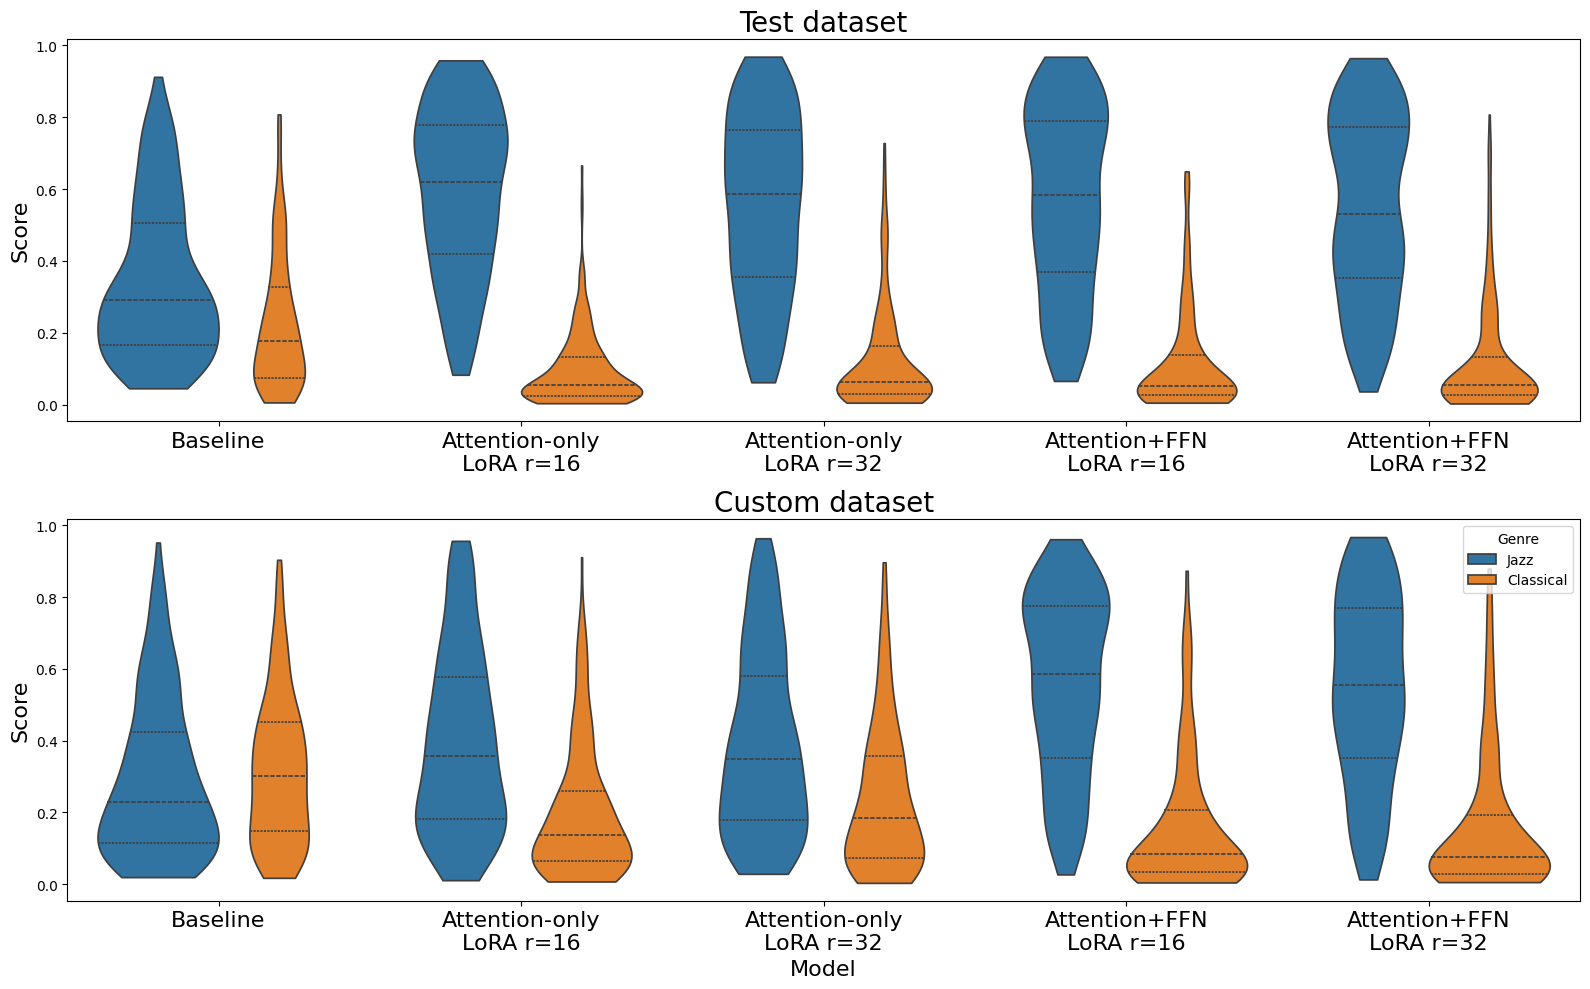

In [53]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

configs = [
    ("baseline", ""),
    ("att", 16),
    ("att", 32),
    ("all", 16),
    ("all", 32),
]

label_map = {
    ("baseline", ""): "Baseline",
    ("att", 16): "Attention-only\nLoRA r=16",
    ("att", 32): "Attention-only\nLoRA r=32",
    ("all", 16): "Attention+FFN\nLoRA r=16",
    ("all", 32): "Attention+FFN\nLoRA r=32",
}

datasets = [
    ("Custom dataset", custom_dataset),
    ("Test dataset", test_dataset),
]

rows = []

for dataset_name, dataset_path in datasets:
    for config in configs:
        model, rank = config

        res_path = os.path.join(
            dataset_path,
            "results",
            f"{model}{rank}_scores.json"
        )

        with open(res_path, "r", encoding="utf-8") as f:
            raw_scores = json.load(f)

        scores = [item for values in raw_scores.values() for item in values]

        config_label = label_map[config]

        for s in scores:
            rows.append({
                "dataset": dataset_name,
                "config": config_label,
                "genre": "Jazz",
                "score": s["jazz"],
            })
            rows.append({
                "dataset": dataset_name,
                "config": config_label,
                "genre": "Classical",
                "score": s["classical"],
            })

df = pd.DataFrame(rows)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharey=True
)

for ax, dataset_name in zip(axes, ["Test dataset", "Custom dataset"]):
    subset = df[df["dataset"] == dataset_name]

    sns.violinplot(
        data=subset,
        x="config",
        y="score",
        hue="genre",
        split=False,
        inner="quartile",
        cut=0,
        ax=ax,
    )

    ax.set_title(dataset_name, fontsize=20)
    ax.set_xlabel("Model" if ax is axes[1] else "", fontsize=16)
    ax.set_ylabel("Score", fontsize=16)
    ax.tick_params(axis="x", rotation=0, labelsize=16)

    # keep legend only on the second subplot
    if ax is axes[0]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Genre")

plt.tight_layout()
plt.savefig("fig/violin_plots.pdf")
plt.show()